# 01 — The complex-path agent

This notebook builds the "complex" branch of the architecture in the [README](../../README.md): a LangGraph ReAct agent that handles the nuanced claims questions.

The re-usable version of the same build lives in `demo/shared/insurance_bot.py`; `02_router_cache.ipynb` and `03_async_work_queue.ipynb` import directly from it, so what you see here is exactly what runs end-to-end.

**Prereqs**
- Redis reachable at `REDIS_URL` (default `redis://localhost:6379`) # TODO: make sure this works in lab environment
- `.env` populated with `MODEL_API_KEY` and `COMPLEX_MODEL_NAME`
- `pip install -r ../scripts/requirements.txt`

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

REPO_ROOT = Path.cwd().parents[1]
load_dotenv(REPO_ROOT / ".env")

COMPLEX_ENDPOINT = os.environ["COMPLEX_MODEL_ENDPOINT"]
COMPLEX_KEY = os.environ["COMPLEX_MODEL_KEY"]
COMPLEX_MODEL = os.environ.get("COMPLEX_MODEL_NAME", "deepseek-r1-distill-qwen-14b")
REDIS_URL = os.environ.get("REDIS_URL", "redis://localhost:6379")

# ChatOpenAI wants the `/v1` base URL, not the full `/v1/chat/completions` path.
def _base_url(endpoint: str) -> str:
    trimmed = endpoint.rstrip('/')
    for suffix in ('/chat/completions', '/completions'):
        if trimmed.endswith(suffix):
            return trimmed[: -len(suffix)]
    return trimmed

COMPLEX_BASE_URL = _base_url(COMPLEX_ENDPOINT)
DATA_DIR = Path.cwd() / "data"
print("model :", COMPLEX_MODEL)
print("base  :", COMPLEX_BASE_URL)
print("redis :", REDIS_URL)
print("data  :", DATA_DIR)

model : deepseek-r1-distill-qwen-14b
base  : https://litellm-prod.apps.maas.redhatworkshops.io/v1
redis : redis://localhost:6379
data  : /Users/robert.shelton/Documents/redhat-ex/Reducing-costs-of-AI-with-Redis-Labs/demo/notebooks/data


## 1. Load mock policy and FAQ data

Stand-ins for the two stores a real claims desk would hit: a policy system of record (`data/policies.json`) and a curated FAQ (`data/insurance_faq.json`). Keeping them as flat JSON keeps the notebook focused on how the agent *uses* them, not on data plumbing.

In [2]:
import json

with open(DATA_DIR / "policies.json") as f:
    POLICIES = {p["policy_id"]: p for p in json.load(f)}

with open(DATA_DIR / "insurance_faq.json") as f:
    FAQ = json.load(f)

print(f"policies: {len(POLICIES)}  |  ids: {list(POLICIES)}")
print(f"faq rows: {len(FAQ)}  |  sample: {FAQ[0]['question']}")

policies: 4  |  ids: ['AUTO-1001', 'AUTO-1002', 'HOME-2001', 'AUTO-1003']
faq rows: 7  |  sample: What documents do I need to file an auto claim?


## 2. FAQ semantic-search helper

The FAQ index lives in Redis alongside the router, cache, and conversation memory — same piece of infra, same client. We embed the questions with `HFTextVectorizer` (the same `all-MiniLM-L6-v2` model the router and cache use), declare an `IndexSchema` with a cosine-distance vector field, and load the rows through `SearchIndex.load`. Lookups go through `VectorQuery` so the retrieval path the agent uses in this notebook is the same one that would serve traffic on OpenShift.

In [3]:
from redis import Redis
from redisvl.utils.vectorize import HFTextVectorizer
from redisvl.schema import IndexSchema
from redisvl.index import SearchIndex
from redisvl.query import VectorQuery

os.environ["TOKENIZERS_PARALLELISM"] = "false"

FAQ_INDEX_NAME = "insurance-faq"

redis_client = Redis.from_url(REDIS_URL)
hf = HFTextVectorizer(model="sentence-transformers/all-MiniLM-L6-v2")

faq_schema = IndexSchema.from_dict({
    "index": {
        "name": FAQ_INDEX_NAME,
        "prefix": FAQ_INDEX_NAME,
        "storage_type": "hash",
    },
    "fields": [
        {"name": "question", "type": "text"},
        {"name": "answer", "type": "text"},
        {"name": "category", "type": "tag"},
        {
            "name": "vector",
            "type": "vector",
            "attrs": {
                "dims": hf.dims,
                "distance_metric": "cosine",
                "algorithm": "flat",
                "datatype": "float32",
            },
        },
    ],
})

faq_index = SearchIndex(faq_schema, redis_client)
faq_index.create(overwrite=True, drop=True)

faq_vectors = hf.embed_many(
    [row["question"] for row in FAQ],
    as_buffer=True,
)
faq_index.load([
    {
        "question": row["question"],
        "answer": row["answer"],
        "category": row["category"],
        "vector": vec,
    }
    for row, vec in zip(FAQ, faq_vectors)
])


def search_faq_local(query: str, k: int = 3):
    vec_query = VectorQuery(
        vector=hf.embed(query),
        vector_field_name="vector",
        num_results=k,
        return_fields=["question", "answer", "category"],
        return_score=True,
    )
    hits = faq_index.query(vec_query)
    return [
        {
            "question": h["question"],
            "answer": h["answer"],
            "category": h["category"],
            "score": 1 - float(h["vector_distance"]),
        }
        for h in hits
    ]


for hit in search_faq_local("rental car while mine is in the shop"):
    print(f"[{hit['score']:.2f}] {hit['question']}")


/Users/robert.shelton/Documents/redhat-ex/Reducing-costs-of-AI-with-Redis-Labs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6764.37it/s]

[0.31] When does rental reimbursement apply?
[0.19] Can I make temporary repairs after home damage?
[0.19] Do I need photos for a windshield claim?


## 3. Define the agent tools

Three narrow tools: FAQ lookup, policy details, and required documents for a given claim type. The docstrings *are* the contract the model sees, so they're written to push the ReAct loop toward calling a tool before falling back to general knowledge.

In [4]:
from langchain_core.tools import tool

@tool
def search_faq(query: str) -> list[dict]:
    """Search insurance FAQ guidance. Returns top matches with answer text."""
    return search_faq_local(query, k=3)

@tool
def get_policy_details(policy_id: str) -> dict:
    """Look up a policy by id (e.g. 'AUTO-1001'). Returns coverages and deductibles."""
    if policy_id not in POLICIES:
        return {"error": f"policy {policy_id} not found", "known_ids": list(POLICIES)}
    return POLICIES[policy_id]

REQUIRED_DOCS = {
    "auto": [
        "date and location of incident",
        "policy number",
        "photos of damage",
        "incident description",
        "police or incident report number",
    ],
    "windshield": [
        "photos of the damaged glass",
        "policy number",
        "date of damage",
    ],
    "homeowners": [
        "photos of damage",
        "policy number",
        "description of what happened",
        "repair estimates",
        "receipts for temporary repairs",
    ],
}

@tool
def list_required_documents(claim_type: str) -> list[str]:
    """List typical documents needed for a claim type (e.g. 'auto', 'windshield', 'homeowners')."""
    return REQUIRED_DOCS.get(claim_type.lower(), [
        "policy number",
        "date and description of incident",
        "any photos or receipts related to the loss",
    ])

TOOLS = [search_faq, get_policy_details, list_required_documents]
print("tools:", [t.name for t in TOOLS])

tools: ['search_faq', 'get_policy_details', 'list_required_documents']


## 4. Build the LLM

Only the complex path pays for the reasoning model — that's the whole point of the routing architecture in the README. This notebook points at Red Hat's MaaS LiteLLM gateway serving `deepseek-r1-distill-qwen-14b`; pointing at OpenAI, Azure, or a local vLLM deployment is a `.env` change, nothing in the code below moves.

In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=COMPLEX_MODEL,
    api_key=COMPLEX_KEY,
    base_url=COMPLEX_BASE_URL,
)

# Sanity check — also prints the token usage the provider reports.
resp = llm.invoke("In one short sentence, say hello as an insurance assistant.")
print(resp.content)
print("usage:", resp.usage_metadata)

Okay, so the user wants me to say hello as an insurance assistant in one short sentence. Let me think about how to approach this.

First, I need to make sure the greeting is friendly and welcoming. Using "Hello" is standard, but maybe adding a smiley emoji would make it more personable. 

Next, I should introduce myself clearly. "Hi, I'm [Your Name], your insurance assistant!" That sounds good. It tells the user who I am and what I do.

Then, I should offer help. Something like "How can I assist you today?" invites the user to share their needs. 

Putting it all together: "Hello! Hi, I'm [Your Name], your insurance assistant! How can I assist you today?" Wait, that's a bit redundant with "Hello" and "Hi" twice. Maybe I should combine them. 

Alternatively, "Hello! I'm [Your Name], your insurance assistant. How can I assist you today?" That flows better. It's friendly, clear, and concise. 

I think that's a solid response. It covers all the necessary points without being too lengthy.
</

## 5. Assemble the ReAct agent

`create_agent` (LangChain v1) stitches the model, the tools, and the system prompt into a compiled LangGraph graph. The system prompt earns its keep: it pins the answer style, blocks the model from inventing dollar amounts or claim statuses, and pushes anything outside claims guidance back to the insurer — the kind of rules you want in place before a demo meets a real customer, not bolted on after.

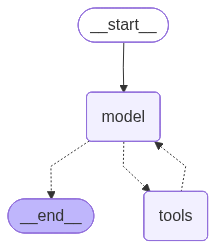

In [6]:
from langchain.agents import create_agent

AGENT_SYSTEM_PROMPT = (
    "You are an insurance claims assistant helping customers navigate "
    "auto and homeowners claims. "
    "If the provided tools can answer the question (FAQ lookup, policy "
    "details, required documents), call them first and ground your answer "
    "in their output. If no tool is relevant, answer from general insurance "
    "best practices.\n\n"
    "Answer style:\n"
    "- Open with a one-sentence direct answer.\n"
    "- Follow with a short bulleted list of concrete next steps or items "
    "(5 bullets max).\n"
    "- Keep the whole reply under ~180 words.\n\n"
    "Output rules (strict):\n"
    "- Output only the final answer. No preamble, no apologies, no "
    "sign-off.\n"
    "- Do not restate the question or summarize what the user said.\n"
    "- Do not narrate your reasoning, plans, or which tools you will call "
    "(\"I'll check...\", \"Let me look up...\", \"First I need to...\").\n"
    "- Do not begin with filler like \"Okay\", \"Sure\", \"Alright\", "
    "\"Let me\", \"So\", \"The user\", or \"I\". Begin directly with the "
    "answer sentence.\n"
    "- Do not emit \"<think>\" or \"</think>\" tags or any chain-of-thought "
    "text in the final reply.\n\n"
    "Hard rules:\n"
    "- Never invent specific dollar amounts, coverage limits, deductibles, "
    "claim numbers, or adjuster contact details. If the user hasn't shared "
    "the specifics, tell them what to check on their policy.\n"
    "- Do not speculate about the status of a specific claim, estimate "
    "payouts, or assign/contact adjusters.\n"
    "- For anything outside claims guidance, tell the user to contact their "
    "insurer directly."
)

agent = create_agent(model=llm, tools=TOOLS, system_prompt=AGENT_SYSTEM_PROMPT)

from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))


In [7]:
import re

_THINK_BLOCK = re.compile(r"<think\b[^>]*>.*?</think>", re.DOTALL | re.IGNORECASE)
_ORPHAN_CLOSE = re.compile(r"\A.*?</think>\s*", re.DOTALL | re.IGNORECASE)

def strip_reasoning(text: str) -> str:
    """Drop <think>...</think> blocks (and orphan </think> leaks) from replies."""
    if not text:
        return text
    cleaned = _THINK_BLOCK.sub("", text)
    if "</think>" in cleaned.lower():
        cleaned = _ORPHAN_CLOSE.sub("", cleaned, count=1)
    return cleaned.strip()

def ask(a, q, tid="jordan-auto-claim"):
    """Invoke a LangGraph agent with a thread_id and return the final reply."""
    out = a.invoke(
        {"messages": [{"role": "user", "content": q}]},
        config={"configurable": {"thread_id": tid}},
    )
    return strip_reasoning(out["messages"][-1].content)

question = (
    "I rear-ended someone in my RAV4 this morning. "
    "What documents should I gather before I file the claim?"
)
print(ask(agent, question))


Gather the following documents before filing your claim:  
- Police report from the accident scene.  
- Photos of the accident scene, your vehicle's damage, and the other vehicle's damage.  
- Exchange information with the other driver, including their contact details, license, insurance, and vehicle registration.  
- Witness statements, if available.  
- Any medical records or bills from injuries sustained.  
- Your insurance policy details and coverage information.  
- Repair estimates or invoices for your vehicle.  

These documents will help expedite the claims process and ensure all necessary information is on file.


## 6. Multi-turn memory with Redis

Conversation state is the first thing that breaks when you move from a notebook to a horizontally scaled service — in-process memory doesn't survive a restart, let alone a second pod. LangGraph handles this with a pluggable `checkpointer`; pointing it at `RedisSaver` means a given `thread_id` resumes across notebook runs today and across OpenShift pods tomorrow, with no code change.

`RedisSaver.from_conn_string` is a context manager, so we build the memory-backed agent inside the `with` block.

In [8]:
from langgraph.checkpoint.redis import RedisSaver

thread_id = "jordan-auto-claim"

with RedisSaver.from_conn_string(REDIS_URL) as checkpointer:
    checkpointer.setup()
    mem_agent = create_agent(
        model=llm, tools=TOOLS, system_prompt=AGENT_SYSTEM_PROMPT, checkpointer=checkpointer
    )

    print("--- turn 1 ---")
    print(ask(mem_agent,
        "Hi, I'm the holder of policy AUTO-1001. I just had a minor fender bender. What do I need to do first?",
        thread_id))

    print("\n--- turn 2 ---")
    print(ask(mem_agent,
        "Got it. Do I need to pay my deductible up front, and how much is it on that policy?",
        thread_id))

    print("\n--- turn 3 ---")
    print(ask(mem_agent,
        "Also — while my car is being repaired, will I have a rental covered?",
        thread_id))


--- turn 1 ---


To address the minor fender bender and navigate the claims process effectively, follow these organized steps:

1. **Contact Your Insurance Company**: 
   - Report the accident promptly by calling your insurance company, logging into their website, or using their mobile app.
   - Provide details such as the time, location, and extent of the damage.

2. **Exchange Information with the Other Driver**: 
   - Immediately exchange contact and insurance details with the other driver involved. This includes names, phone numbers, and insurance information.

3. **Review Policy Documents**: 
   - Check your policy documents to understand your deductible amount and whether it needs to be paid upfront. If unclear, contact your insurance company for clarification.

4. **Document the Damage**: 
   - Take photos of the accident and damage to assist the claims process. This documentation can be crucial for insurance purposes.

5. **Rental Car Coverage**: 
   - Check your policy for details on rental ca

To address your concerns about the insurance claim after a minor fender bender, here is a concise and organized summary of the key points:

1. **Deductible Payment**: 
   - You may need to pay your deductible upfront before the insurance company begins covering the costs. 
   - Check your insurance policy or contact your insurance company to confirm this requirement.

2. **Deductible Amount**: 
   - Review your insurance policy or contact your insurance agent to find the exact deductible amount. 
   - This information is typically located in the collision coverage section of your policy.

3. **Exceptions for Minor Damages**: 
   - If the repair costs are less than the deductible, you may not need to pay the full deductible. 
   - Consult your insurance company to confirm any exceptions that apply to your situation.

4. **Impact on Credit Score**: 
   - Paying the deductible is generally an out-of-pocket expense and does not affect your credit score. 
   - However, it's advisable to ver

Check your policy details to confirm if rental coverage is included. If unsure, contact your insurance company directly to confirm whether rental coverage is available for this claim.


## Next

This is the expensive branch of the architecture running in isolation. `02_router_cache.ipynb` puts the optimization layer in front of it:

1. a **semantic router** that pushes simple account questions to a cheaper non-reasoning model and refuses prompt-injection attempts before they ever hit the agent
2. a **semantic cache** fed only by 👍 user feedback, so repeat questions return in milliseconds without another round-trip to the reasoning model

`demo/shared/insurance_bot.py` is the same build packaged for reuse — open it alongside the next notebook to see the piece parts as a plain Python module.

`03_async_work_queue.ipynb` then shows the same pipeline running behind a [redis-agent-kit](https://pypi.org/project/redis-agent-kit/) worker, which is what you'd actually deploy on OpenShift.